# Image cube: FITS ↔ HDF5 and 12-panel plots

Demo file: `../demofile/ovro-lwa-352.lev1_mfs_10s.2026-05-14T200001Z.image_I.hdf`

(See `spec_plot.ipynb` for dynamic spectrum FITS.)

1. **Recover** — HDF5 → FITS
2. **Compress** — FITS → HDF5
3. **Consistency check**
4. **`slow_pipeline_default_plot`** — 12-panel OVRO-LWA layout ([reference](https://github.com/ovro-eovsa/ovro-lwa-solar/blob/b55f56d5/ovrolwasolar/visualization.py#L75))

```bash
pip install git+https://github.com/ovro-eovsa/lwa-solar-util.git
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import lwasolarutl as lsu

REPO = Path("..").resolve() if (Path("..") / "demofile").exists() else Path(".").resolve()
DEMO = REPO / "demofile"
HDF_IN = DEMO / "ovro-lwa-352.lev1_mfs_10s.2026-05-14T200001Z.image_I.hdf"
FITS_RECOVERED = DEMO / "recovered_from_hdf.fits"
HDF_OUT = DEMO / "recompressed_from_fits.hdf"

print("Demo HDF:", HDF_IN)
print("Exists:", HDF_IN.exists())

Demo HDF: /fast/peijinz/lwa-solar-util/demofile/ovro-lwa-352.lev1_mfs_10s.2026-05-14T200001Z.image_I.hdf
Exists: True


## 1. Recover FITS from compressed HDF5

In [2]:
lsu.file.recover_fits_from_h5(str(HDF_IN), str(FITS_RECOVERED))
print(f"Wrote {FITS_RECOVERED} ({FITS_RECOVERED.stat().st_size / 1e6:.1f} MB)")

Wrote /fast/peijinz/lwa-solar-util/demofile/recovered_from_hdf.fits (7.9 MB)


## 2. Compress FITS back to HDF5

In [3]:
lsu.file.compress_fits_to_h5(str(FITS_RECOVERED), str(HDF_OUT))
print(f"Wrote {HDF_OUT} ({HDF_OUT.stat().st_size / 1e6:.1f} MB)")

Wrote /fast/peijinz/lwa-solar-util/demofile/recompressed_from_fits.hdf (3.3 MB)


## 3. Check consistency (recovered FITS vs re-compressed HDF5)

In [4]:
pass_code = lsu.file.check_h5_fits_consistency(
    str(FITS_RECOVERED),
    str(HDF_OUT),
    work_dir=str(DEMO) + "/",
)
print("check_h5_fits_consistency:", pass_code, "(0 = OK)")

check_h5_fits_consistency: 0 (0 = OK)


## 4. Default 12-panel plot

`slow_pipeline_default_plot` expects a FITS file readable by `lwasolarutl.ndfits` (use the recovered FITS above). It plots 12 frequencies on a 3×4 grid with solar coordinates.

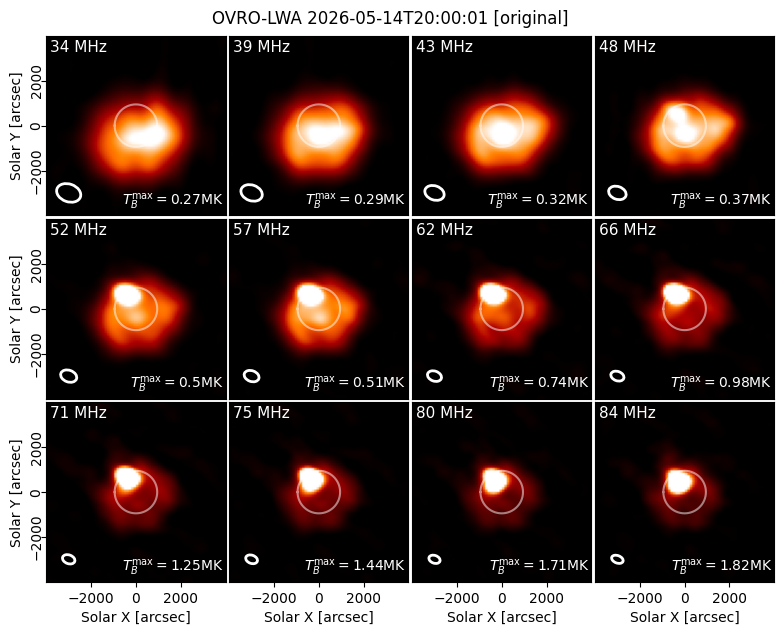

In [5]:
fig, axes = lsu.visualization.slow_pipeline_default_plot(
    str(FITS_RECOVERED),
    add_logo=False,
)
plt.show()